### Generative Adversarial Networks (GANs)

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data
from torchvision import datasets, transforms

mnist_data = datasets.MNIST('data', train=True, download=True, transform=transforms.ToTensor())

100%|██████████| 9.91M/9.91M [00:01<00:00, 6.06MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 160kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.51MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.06MB/s]


In [2]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 7)
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 7),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [3]:
def train(model, num_epochs=5, batch_size=64, learning_rate=1e-3):
    torch.manual_seed(42)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
    train_loader = torch.utils.data.DataLoader(mnist_data, batch_size=batch_size, shuffle=True)
    outputs = []
    for epoch in range(num_epochs):
        for data in train_loader:
            img, label = data
            recon = model(img)
            loss = criterion(recon, img)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        print('Epoch:{}, Loss:{:.4f}'.format(epoch+1, float(loss)))
        outputs.append((epoch, img, recon),)
        torch.save(model.state_dict(), "autoencoder%d.pt" % epoch)
    return outputs

model = Autoencoder()
outputs = train(model, num_epochs=5)

/tmp/ipykernel_1827/3781233063.py:16: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print('Epoch:{}, Loss:{:.4f}'.format(epoch+1, float(loss)))


Epoch:1, Loss:0.0107
Epoch:2, Loss:0.0053
Epoch:3, Loss:0.0037
Epoch:4, Loss:0.0037
Epoch:5, Loss:0.0027


In [4]:
# Choose a model to load -- after 2 epochs of training
ckpt = torch.load("autoencoder1.pt")
model.load_state_dict(ckpt)

<All keys matched successfully>

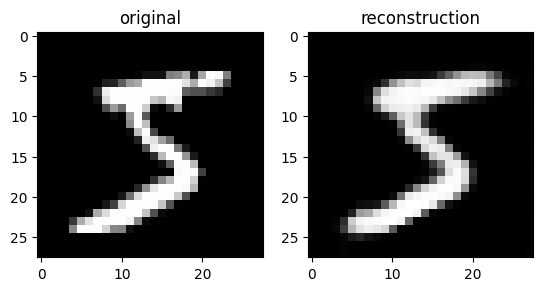

In [ ]:
original = mnist_data[0][0].unsqueeze(0)
emb = model.encoder(original)
recon_img = model.decoder(emb).detach().numpy()[0,0,:,:]

plt.subplot(1,2,1)
plt.title("original")
plt.imshow(original[0][0], cmap='gray')

plt.subplot(1,2,2)
plt.title("reconstruction")
plt.imshow(recon_img, cmap='gray')

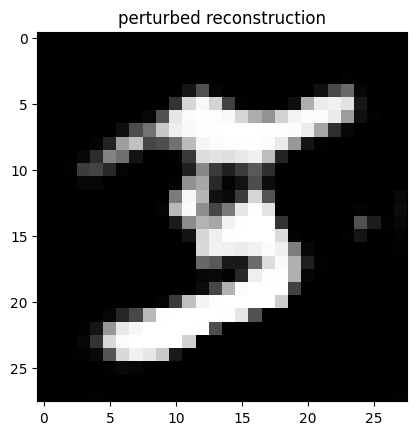

In [ ]:
x = emb + 10 * torch.randn(1, 64, 1, 1) #

img = model.decoder(x)[0,0,:,:]
img = img.detach().numpy()
plt.title("perturbed reconstruction")
plt.imshow(img, cmap='gray')

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Discriminator(nn.Module):

    def __init__(self):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 1)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = F.leaky_relu(self.fc1(x), 0.2)
        x = self.dropout(x)
        x = F.leaky_relu(self.fc2(x), 0.2)
        x = self.dropout(x)
        x = F.leaky_relu(self.fc3(x), 0.2)
        x = self.dropout(x)
        out = self.fc4(x)
        return out

class Generator(nn.Module):

    def __init__(self):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(100, 32)
        self.fc2 = nn.Linear(32, 64)
        self.fc3 = nn.Linear(64, 128)
        self.fc4 = nn.Linear(128, 28*28)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = F.leaky_relu(self.fc1(x), 0.2)
        x = self.dropout(x)
        x = F.leaky_relu(self.fc2(x), 0.2)
        x = self.dropout(x)
        x = F.leaky_relu(self.fc3(x), 0.2)
        x = self.dropout(x)
        out = torch.tanh(self.fc4(x))
        return out

D = Discriminator()
G = Generator()

In [ ]:
from torchvision import datasets
import torchvision.transforms as transforms
import numpy as np
import torch
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.utils.data

def train(G, D, lr=0.002, batch_size=64, num_epochs=20):

    rand_size = 100
    d_optimizer = optim.Adam(D.parameters(), lr)
    g_optimizer = optim.Adam(G.parameters(), lr)
    criterion = nn.BCEWithLogitsLoss()
    train_data = datasets.MNIST('data', train=True, download=True, transform=transforms.ToTensor())
    train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)

    samples = []
    losses = []
    sample_size=16
    test_noise = np.random.uniform(-1, 1, size=(sample_size, rand_size))
    test_noise = torch.from_numpy(test_noise).float()

    for epoch in range(num_epochs):
        D.train()
        G.train()

        for batch_i, (real_images, _) in enumerate(train_loader):
            batch_size = real_images.size(0)
            real_images = real_images*2 - 1
            d_optimizer.zero_grad()

            D_real = D(real_images)
            labels = torch.ones(batch_size)
            d_real_loss = criterion(D_real.squeeze(), labels)

            z = np.random.uniform(-1, 1, size=(batch_size, rand_size))
            z = torch.from_numpy(z).float()
            fake_images = G(z)

            D_fake = D(fake_images)
            labels = torch.zeros(batch_size) # Fake labels = 0
            d_fake_loss = criterion(D_fake.squeeze(), labels)

            d_loss = d_real_loss + d_fake_loss
            d_loss.backward()
            d_optimizer.step()
            g_optimizer.zero_grad()

            z = np.random.uniform(-1, 1, size=(batch_size, rand_size))
            z = torch.from_numpy(z).float()
            fake_images = G(z)

            D_fake = D(fake_images)
            labels = torch.ones(batch_size) # Flipped labels

            g_loss = criterion(D_fake.squeeze(), labels)
            g_loss.backward()
            g_optimizer.step()

        print('Epoch [%d/%d], d_loss: %.4f, g_loss: %.4f, '
              % (epoch + 1, num_epochs, d_loss.item(), g_loss.item()))

        losses.append((d_loss.item(), g_loss.item()))

        G.eval()
        D.eval()
        test_images = G(test_noise)

        plt.figure(figsize=(9, 3))
        for k in range(16):
            plt.subplot(2, 8, k+1)
            plt.imshow(test_images[k,:].data.numpy().reshape(28, 28), cmap='Greys')
        plt.show()

    return losses

Epoch [1/20], d_loss: 1.2085, g_loss: 0.8960, 


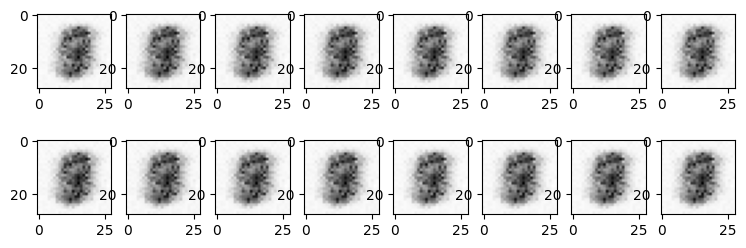

Epoch [2/20], d_loss: 1.2871, g_loss: 0.7361, 


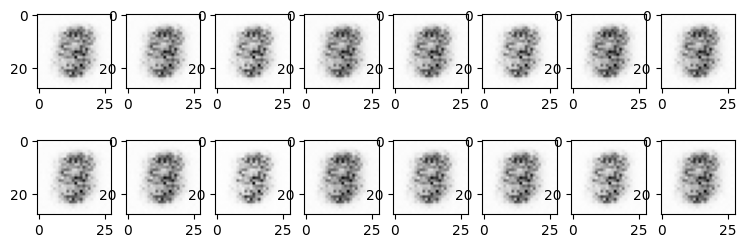

Epoch [3/20], d_loss: 1.4922, g_loss: 0.7899, 


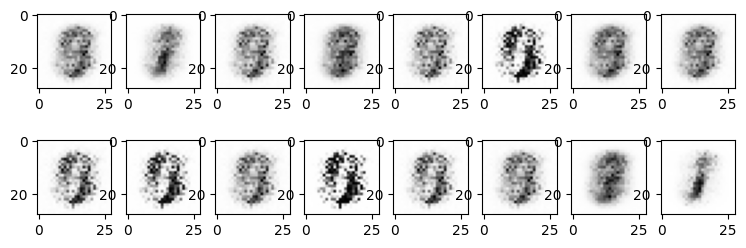

Epoch [4/20], d_loss: 1.2035, g_loss: 1.1222, 


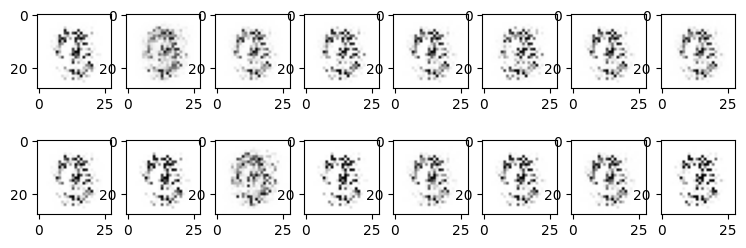

Epoch [5/20], d_loss: 0.0024, g_loss: 55.7818, 


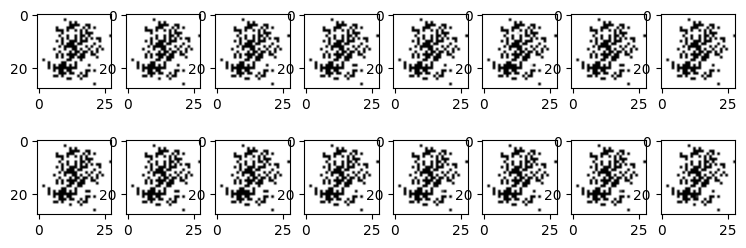

Epoch [6/20], d_loss: 0.0022, g_loss: 73.6012, 


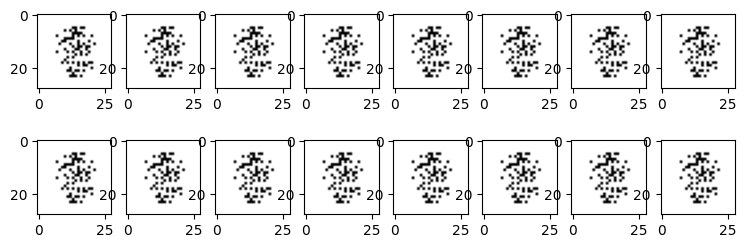

Epoch [7/20], d_loss: 0.0019, g_loss: 124.1772, 


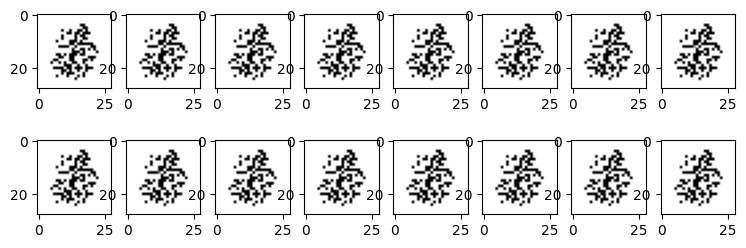

Epoch [8/20], d_loss: 0.0013, g_loss: 78.2230, 


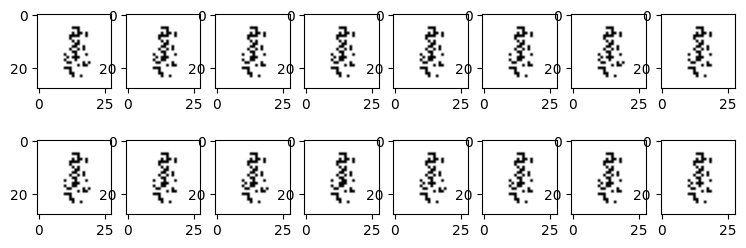

Epoch [9/20], d_loss: 0.0053, g_loss: 160.1381, 


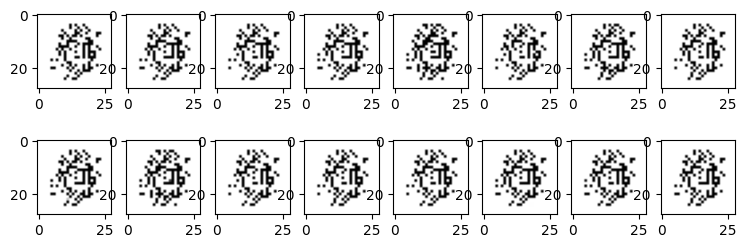

Epoch [10/20], d_loss: 0.0002, g_loss: 42.9537, 


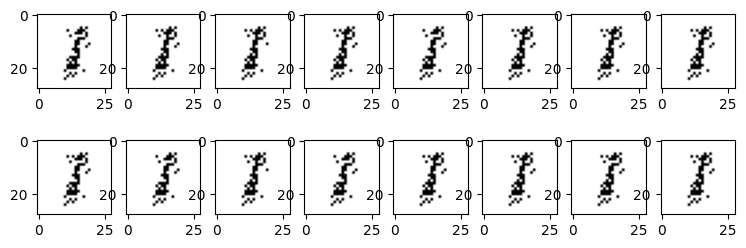

Epoch [11/20], d_loss: 0.0013, g_loss: 72.6102, 


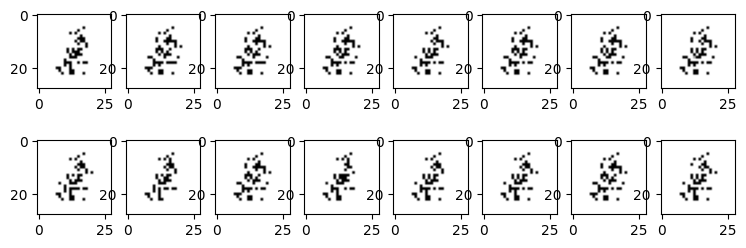

Epoch [12/20], d_loss: 0.0012, g_loss: 42.7558, 


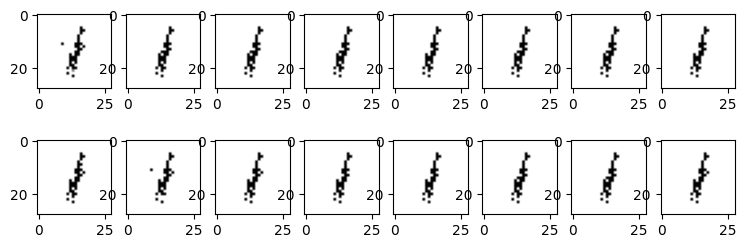

Epoch [13/20], d_loss: 0.0000, g_loss: 36.5760, 


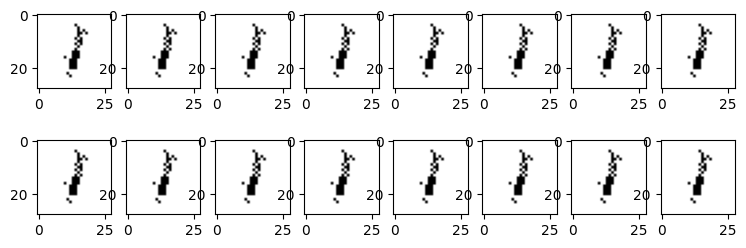

Epoch [14/20], d_loss: 0.0002, g_loss: 73.5791, 


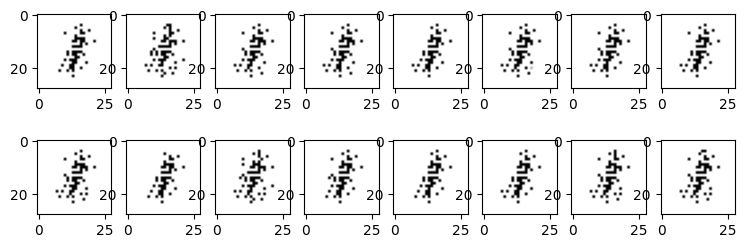

Epoch [15/20], d_loss: 0.0306, g_loss: 47.1249, 


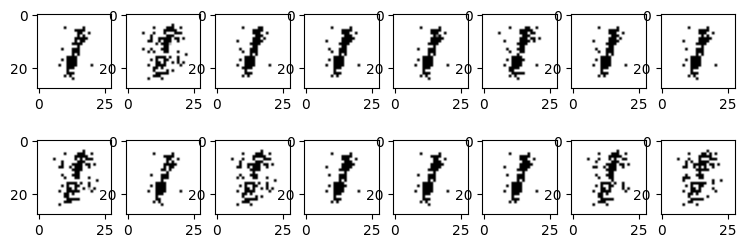

Epoch [16/20], d_loss: 0.0011, g_loss: 44.6713, 


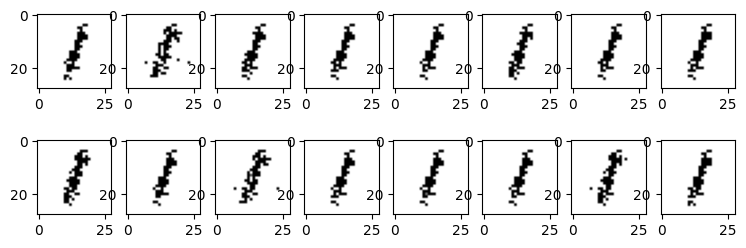

Epoch [17/20], d_loss: 0.0016, g_loss: 34.1656, 


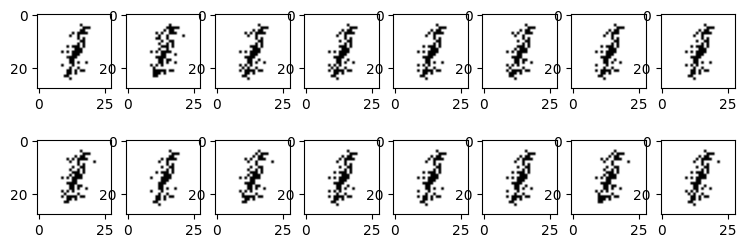

Epoch [18/20], d_loss: 0.0012, g_loss: 94.8969, 


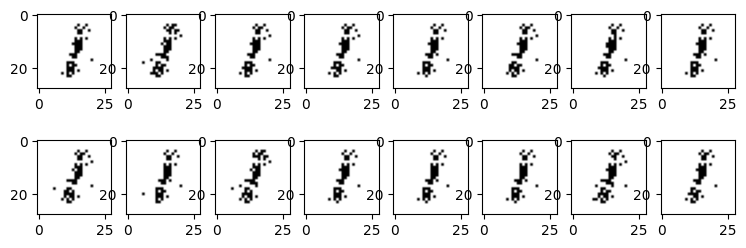

Epoch [19/20], d_loss: 0.0016, g_loss: 58.3173, 


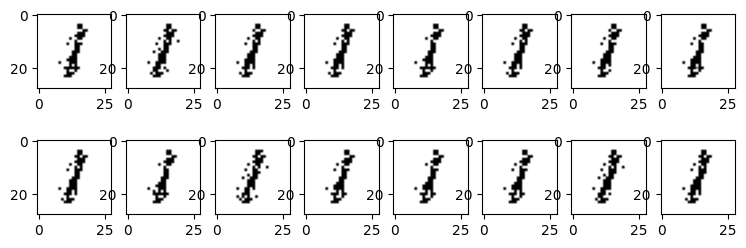

Epoch [20/20], d_loss: 0.0008, g_loss: 49.8253, 


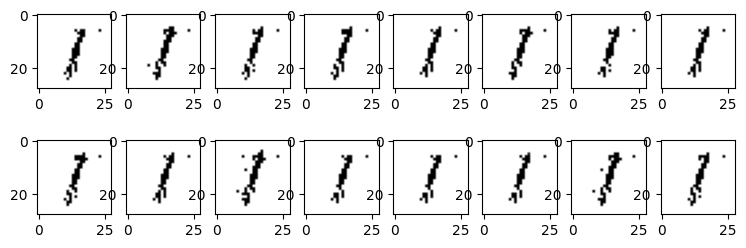

In [9]:
losses = train(G, D, lr=0.002, batch_size=64, num_epochs=20)

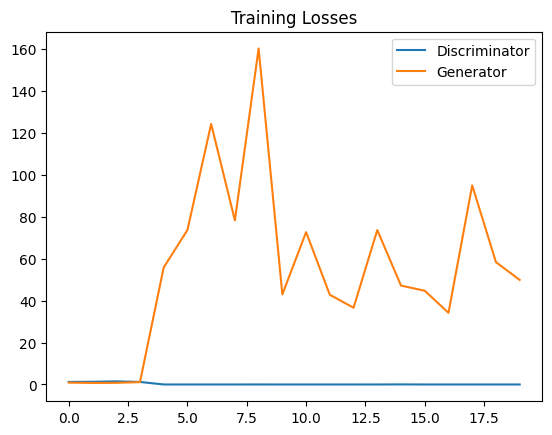

In [10]:
fig, ax = plt.subplots()
losses = np.array(losses)
plt.plot(losses.T[0], label='Discriminator')
plt.plot(losses.T[1], label='Generator')
plt.title("Training Losses")
plt.legend()